Generate DataSet

In [1]:
import numpy as np
import pandas as pd

data = []

for _ in range(1000):
    alpha = np.random.rand()
    beta = np.sqrt(1 - alpha**2)

    # Labeling rule
    if alpha > 0.3 and beta > 0.3:
        label = 1   # entangled-like
    else:
        label = 0   # separable-like

    data.append([alpha, beta, label])

df = pd.DataFrame(data, columns=['alpha', 'beta', 'label'])

print(df.head())

# Save dataset
df.to_csv("C:\\Users\\Sathwika\\OneDrive\\Desktop\\BTP 2\\quantum_data.csv", index=False)

      alpha      beta  label
0  0.929155  0.369691      1
1  0.356865  0.934156      1
2  0.576511  0.817090      1
3  0.735183  0.677869      1
4  0.577288  0.816541      1


In [2]:
print(df.shape)

(1000, 3)


Visualization

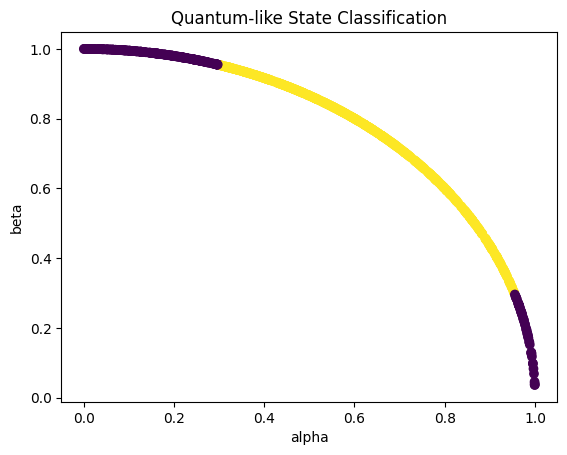

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df['alpha'], df['beta'], c=df['label'])
plt.xlabel("alpha")
plt.ylabel("beta")
plt.title("Quantum-like State Classification")
plt.show()

3.Machine Learning Mode;

In [4]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features and labels
X = df[['alpha', 'beta']]
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.99
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        72
           1       0.98      1.00      0.99       128

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



In [6]:
df['alpha_sq'] = df['alpha']**2
df['beta_sq'] = df['beta']**2
df['difference'] = abs(df['alpha'] - df['beta'])
df['product'] = df['alpha'] * df['beta']

print(df.head())

      alpha      beta  label  alpha_sq   beta_sq  difference   product
0  0.929155  0.369691      1  0.863329  0.136671    0.559464  0.343500
1  0.356865  0.934156      1  0.127352  0.872648    0.577291  0.333367
2  0.576511  0.817090      1  0.332364  0.667636    0.240579  0.471061
3  0.735183  0.677869      1  0.540494  0.459506    0.057314  0.498358
4  0.577288  0.816541      1  0.333261  0.666739    0.239253  0.471379


Retrain Model with New Features

In [7]:
X = df[['alpha', 'beta', 'alpha_sq', 'beta_sq', 'difference', 'product']]
y = df['label']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("New Accuracy:", accuracy_score(y_test, pred))

New Accuracy: 1.0


Feature Importance

In [8]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

difference    0.366604
product       0.252746
alpha         0.124504
beta          0.103073
alpha_sq      0.082585
beta_sq       0.070489
dtype: float64


SHAP Explainability

In [9]:
import sys
!{sys.executable} -m pip install shap


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


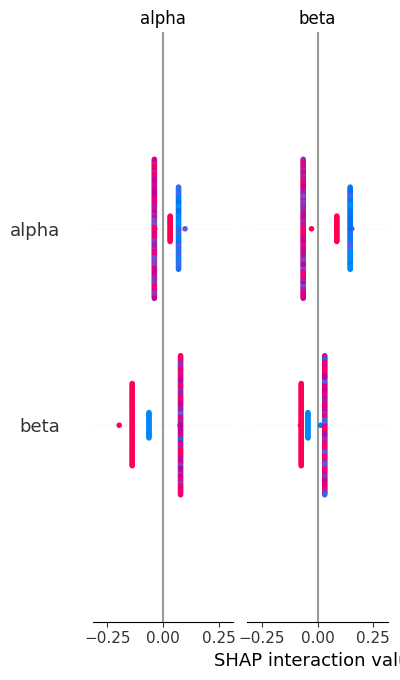

In [10]:
import shap

# Create explainer
explainer = shap.TreeExplainer(model)

# Get SHAP values
shap_values = explainer.shap_values(X_test)

# Plot summary
shap.summary_plot(shap_values, X_test)

In [11]:
!pip install streamlit